# Grover's Algorithm

This notebook builds Grover's algorithm with circuit diagrams and result plots.

**The problem:** you have a list of N unsorted items with exactly one
"winner" and a black box that can tell you whether a given item is the
winner. How many times do you need to query the black box to find it?

- **Classically**, there's no better approach than checking items one at
  a time. On average that's **N/2** queries, and **N** in the worst case.
- **Grover's algorithm** finds it in roughly **√N** queries on a
  quantum computer.


## Setup

Install dependencies if needed (uncomment below)

In [1]:
# !pip install qiskit qiskit-aer matplotlib numpy

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
import numpy as np
import math
import random

%matplotlib inline

## 1) The classical way

Let's set up the example this notebook uses: a
random list of 10 numbers with one "winner" and a "black box" that
checks whether a given number is the winner.


In [2]:
# create a random list and choose a random correct number
random.seed(7)
my_list = random.sample(range(1, 101), 10)
winner = random.choice(my_list)
print(f"winner is {winner} out of list:")
print(my_list)

winner is 42 out of list:
[42, 20, 51, 84, 7, 10, 69, 13, 47, 75]


In [4]:
# define the oracle / black box that identifies if a number is a winner
def black_box(trial):
    return trial == winner

# classical way: check items one at a time until we hit the winner
for index, trial_number in enumerate(my_list):
    if black_box(trial_number):
        print(f"winner found at index {index}")
        print(f"{index + 1} calls to the black box used")
        break

winner found at index 0
1 calls to the black box used


We get lucky or unlucky depending on where the winner happened to sit
in the list. On average,
across many random lists, a linear search needs about N/2 queries, and N
in the worst case (winner is last). We'll verify this with many trials in notebook 2.

Now let's see how a quantum computer approaches the same problem.


## 2) The quantum oracle

On a quantum computer, we don't have to check items one at a time. Instead we
put all N possibilities into a **superposition** and query the
black box on all of them *simultaneously*. The catch is that the
answer comes back as something we can't read off directly.

For a 2-qubit example (N = 4 possible states: `00`, `01`, `10`, `11`),
suppose the winning state is `11`. The oracle we need is a circuit that
flips the sign of the `11` amplitude and leaves the other three alone.
A **controlled-Z gate** does exactly this: it only introduces a -1
phase when both qubits are `1`.


In [5]:
# define the oracle circuit for winner = |11> (2 qubit example)
oracle_11 = QuantumCircuit(2, name="oracle")
oracle_11.cz(0, 1)  # flips the sign of |11> only, leaves the rest untouched
oracle_11.draw()

q_0: ─■─
      │ 
q_1: ─■─

### Checking the oracle works

To verify this, we prepare the equal superposition of all 4 states
(Hadamard on each qubit) and feed it through the oracle. If the oracle
is correct, we should get back the same equal superposition, but with
the `11` amplitude flipped negative.


In [6]:
# prepare superposition and apply the oracle
check_circ = QuantumCircuit(2)
check_circ.h([0, 1])
check_circ.append(oracle_11.to_gate(), [0, 1])
check_circ.save_statevector()

backend = AerSimulator(method="statevector")
transpiled = transpile(check_circ, backend)
result = backend.run(transpiled).result()
sv = result.get_statevector()

print("Statevector (amplitudes for |00>, |01>, |10>, |11>):")
print(np.around(sv, 2))

Statevector (amplitudes for |00>, |01>, |10>, |11>):
[ 0.5+0.j  0.5+0.j  0.5+0.j -0.5+0.j]


All four amplitudes still have magnitude 0.5 (equal superposittion) but the `11` amplitude is now **negative**. That
negative sign is invisible to a direct measurement (probabilities come
from squaring the amplitude, and the sign disappears). The next piece is the
diffuser, which converts that hidden sign flip into a visible 'boost' in
probability.


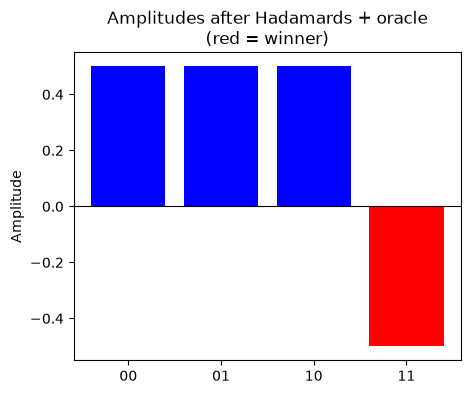

In [9]:
# visualize the amplitudes to make the phase flip obvious
labels = ["00", "01", "10", "11"]
amplitudes = np.real(np.around(sv, 2))

plt.figure(figsize=(5, 4))
bars = plt.bar(labels, amplitudes, color=["blue" if a > 0 else "red" for a in amplitudes])
plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("Amplitude")
plt.title("Amplitudes after Hadamards + oracle\n(red = winner)")
plt.ylim(-0.55, 0.55)
plt.show()

## 3) The diffuser

The oracle marks the winner with a hidden phase flip, but a measurement
right now would still give us each of the 4 outcomes with equal 25%
probability.

The **diffuser** is a reflection operation that converts that phase
flip into an actual boost in measurement probability. Suppose we have our winning state |W> and our superposition state |S>, where each one of our input sates are equally likely. If we consider these 2 states as vectors in space which are almost (but not) orthogonal, then we can come up with a new state within the span of |W> and |S>, |S'>, which is orthogonal to |W>. So when we apply our oracle to |S>, the oracle flips the sign of the winning state (component of |S>). Geometrically this is like reflecting |S> about |S'>. When we apply the reflection operator, it reflects that new vector about the original |S> vector. When we repeat this, the result gets closer and closer to out winning vector/state.

We aim to Hadamard everything back to the `|00...0>`
basis, apply a phase flip to everything **except** `|00...0>`, then
Hadamard again.


In [10]:
# reflection / diffuser operator for 2 qubits
diffuser_2q = QuantumCircuit(2, name="diffuser")
diffuser_2q.h([0, 1])
diffuser_2q.z([0, 1])
diffuser_2q.cz(0, 1)
diffuser_2q.h([0, 1])
diffuser_2q.draw()

┌───┐┌───┐   ┌───┐
q_0: ┤ H ├┤ Z ├─■─┤ H ├
     ├───┤├───┤ │ ├───┤
q_1: ┤ H ├┤ Z ├─■─┤ H ├
     └───┘└───┘   └───┘

## 4) one full Grover iteration

One **Grover iteration** = oracle, then diffuser. For N = 4, exactly
one iteration is enough to find the winner with 100% certainty (in general it takes ~√N
iterations, see Part 5).


In [11]:
grover_circ = QuantumCircuit(2, 2)
grover_circ.h([0, 1])                          # step 1: superposition
grover_circ.append(oracle_11.to_gate(), [0, 1])   # step 2: oracle
grover_circ.append(diffuser_2q.to_gate(), [0, 1]) # step 3: diffuser
grover_circ.measure([0, 1], [0, 1])
grover_circ.draw()

┌───┐┌─────────┐┌───────────┐┌─┐   
q_0: ┤ H ├┤0        ├┤0          ├┤M├───
     ├───┤│  oracle ││  diffuser │└╥┘┌─┐
q_1: ┤ H ├┤1        ├┤1          ├─╫─┤M├
     └───┘└─────────┘└───────────┘ ║ └╥┘
c: 2/══════════════════════════════╩══╩═
                                   0  1

In [15]:
backend = AerSimulator()
transpiled = transpile(grover_circ, backend)
job = backend.run(transpiled, shots=1)
job.result().get_counts()

{'11': 1}

We see that we obtain our winner with only one call to the oracle.


## 5)Generalizing to any N

The circuits above were made for a fixed 2 qubit example with
winner = `11`. Real usage needs this to work for any number of
qubits and any winner. Here's the general process:

- **Oracle:** flip the sign of an arbitrary target by first
  applying X-gates to every qubit that should be `0` in the target
  (temporarily mapping the target to `|11...1>`), applying a
  multi-controlled Z (built from H + multi-controlled-X + H), then
  undoing the X-gates.
- **Diffuser:** the same idea as before, generalized to n qubits.
- **Number of iterations:** the well known result is that
  **r ≈ (π/4)·√N − 1/2** iterations maximizes the success probability
  (for one marked item out of N). Too few or too many iterations can
  reduce your odds - Grover's algorithm can "overshoot"
 

In [19]:
def build_oracle(n_qubits, winner):
    #Phase oracle: flips the sign of the |winner> basis state only.
    bits = format(winner, f"0{n_qubits}b")
    qc = QuantumCircuit(n_qubits, name="oracle")

    flip_qubits = [i for i, b in enumerate(reversed(bits)) if b == "0"]
    if flip_qubits:
        qc.x(flip_qubits)

    if n_qubits == 1:
        qc.z(0)
    else:
        qc.h(n_qubits - 1)
        qc.mcx(list(range(n_qubits - 1)), n_qubits - 1)
        qc.h(n_qubits - 1)

    if flip_qubits:
        qc.x(flip_qubits)

    return qc.to_gate()


def build_diffuser(n_qubits):
    #Reflection about the equal-superposition state |s>
    qc = QuantumCircuit(n_qubits, name="diffuser")
    qc.h(range(n_qubits))
    qc.x(range(n_qubits))

    if n_qubits == 1:
        qc.z(0)
    else:
        qc.h(n_qubits - 1)
        qc.mcx(list(range(n_qubits - 1)), n_qubits-1)
        qc.h(n_qubits-1)

    qc.x(range(n_qubits))
    qc.h(range(n_qubits))
    return qc.to_gate()


def optimal_iterations(n_qubits):
    #r ~= (pi/4)*sqrt(N) - 1/2, the Grover iteration count result.
    n = 2 ** n_qubits
    return max(1, round((math.pi / 4) * math.sqrt(n) - 0.5))


def build_grover_circuit(n_qubits, winner, iterations=None):
    if iterations is None:
        iterations = optimal_iterations(n_qubits)

    oracle = build_oracle(n_qubits, winner)
    diffuser = build_diffuser(n_qubits)

    qc = QuantumCircuit(n_qubits, n_qubits)
    qc.h(range(n_qubits))
    for _ in range(iterations):
        qc.append(oracle, range(n_qubits))
        qc.append(diffuser, range(n_qubits))
    qc.measure(range(n_qubits), range(n_qubits))
    return qc


def run_grover(n_qubits, winner, iterations=None, shots=1024, seed=None):
    if iterations is None:
        iterations = optimal_iterations(n_qubits)
    backend = AerSimulator(seed_simulator=seed)
    qc = build_grover_circuit(n_qubits, winner, iterations=iterations)
    transpiled = transpile(qc, backend)
    counts = backend.run(transpiled, shots=shots).result().get_counts()
    winner_bits = format(winner, f"0{n_qubits}b")
    success_probability = counts.get(winner_bits, 0) / shots
    return counts, iterations, success_probability

Let's try it on a bigger example: 4 qubits (N = 16 possibilities), winner = 11

N = 16, winner = 11 (1011), iterations used = 3
success probability = 0.966


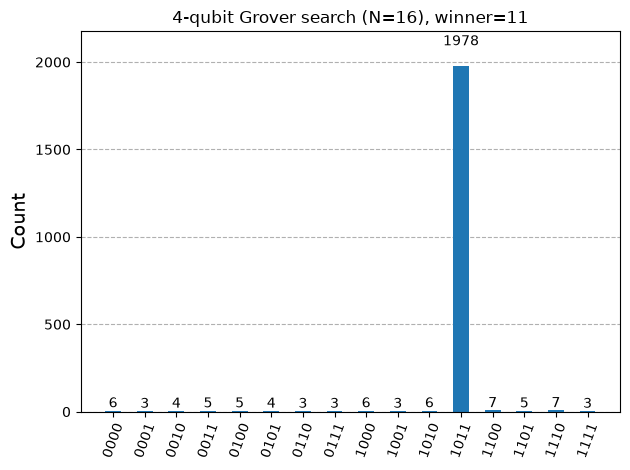

In [21]:
n_qubits = 4
winner = 11

counts, iterations, success = run_grover(n_qubits, winner, shots=2048, seed=42)
print(f"N = {2**n_qubits}, winner = {winner} ({format(winner, f'0{n_qubits}b')}), "
      f"iterations used = {iterations}")
print(f"success probability = {success:.3f}")

plot_histogram(counts, title=f"4-qubit Grover search (N=16), winner={winner}")
plt.show()

Even though there are 16 possible answers, Grover's algorithm
concentrates almost all the measurement probability onto the correct
one after just **3 iterations** - versus a classical average of ~8
queries and worst case of 16.


## 6) Overshooting

Grover's algorithm doesn't just get better the more iterations you
run - success probability rises to a peak near the optimal iteration
count and then falls back down if you keep going. This is the
"overshoot" phenomenon, and it's why the (π/4)·√N formula matters.

We can sweep the iteration count for a fixed problem (N = 32) and watch
the success probability rise and fall.


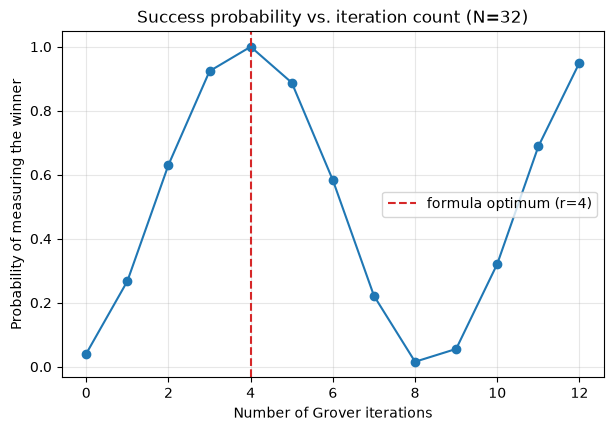

In [22]:
n_qubits = 5   # N = 32
winner = 10

iteration_range = range(0, 13)
success_probs = []

for r in iteration_range:
    counts, _, success = run_grover(n_qubits, winner, iterations=max(r, 0) if r > 0 else 0,
                                     shots=1024, seed=42)
    success_probs.append(success)

optimal_r = optimal_iterations(n_qubits)

plt.figure(figsize=(7, 4.5))
plt.plot(list(iteration_range), success_probs, "o-", color="#1f77b4")
plt.axvline(optimal_r, color="#d62728", linestyle="--",
            label=f"formula optimum (r={optimal_r})")
plt.xlabel("Number of Grover iterations")
plt.ylabel("Probability of measuring the winner")
plt.title(f"Success probability vs. iteration count (N=32)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Notice the peak lands right where the formula predicts, and then
probability drops again as you keep iterating.

## Where to go next

This notebook built the algorithm and showed it working correctly for
individual examples. The companion notebook,
**`Scaling_Comparison.ipynb`**, runs both the classical
search and this generalized Grover implementation across many values of
N (2 up to 256) and plots the O(N) vs O(√N) scaling.
